# miniHOD demo

Fast 6-parameter HOD populator with a C backend.
This notebook covers basic usage, then validates against halotools Zheng07.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time
from miniHOD import HOD

plt.rcParams.update({
    'figure.dpi': 140, 'figure.facecolor': 'white',
    'font.size': 11, 'axes.linewidth': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'legend.frameon': False, 'legend.fontsize': 9,
})

In [16]:
# Mock halo catalog: 2.5M halos, 1 Gpc/h box, approximate Tinker+08 mass function
BOX = 1000.0
rng = np.random.default_rng(42)

# rejection-sample a realistic mass function: dn/dlogM ~ M^{-0.9} exp(-(M/M*)^0.6)
logM_prop = rng.uniform(11.5, 15.2, 25_000_000)
M_prop = 10**logM_prop
w = M_prop**(-0.9) * np.exp(-(M_prop / 10**13.8)**0.6)
halo_masses = M_prop[rng.uniform(size=len(w)) < w / w.max()][:2_500_000]
N = len(halo_masses)

halo_pos = rng.uniform(0, BOX, (N, 3))
halo_vel = rng.normal(0, 300, (N, 3))

# R200m from spherical overdensity: M = (4/3) pi R^3 * 200 * rho_m
rho_m = 2.775e11 * 0.3  # Msun/h / (Mpc/h)^3, Omega_m=0.3
halo_rvir = (3 * halo_masses / (4 * np.pi * 200 * rho_m))**(1/3)

print(f'{N:,} halos, logM range [{np.log10(halo_masses).min():.1f}, {np.log10(halo_masses).max():.1f}]')

2,500,000 halos, logM range [11.5, 15.1]


In [17]:
model = HOD(halo_masses, halo_pos, halo_vel, halo_rvir, box_size=BOX)

galaxies = model.populate(logMmin=12.5, sigma_logM=0.5, fmax=1.0,
                          logMsat=13.5, logMcut=11.5, alpha=1.0, seed=42)

pos, vel = galaxies['pos'], galaxies['vel']
is_cen = galaxies['is_central']
halo_idx = galaxies['halo_idx']

print(f'Ngal = {len(pos):,}  ({is_cen.sum():,} cen, {(~is_cen).sum():,} sat)')
print(f'n_gal = {len(pos)/BOX**3:.4e} (Mpc/h)^-3')

Ngal = 427,135  (343,771 cen, 83,364 sat)
n_gal = 4.2713e-04 (Mpc/h)^-3


In [18]:
# fix logMmin to hit a target number density (bisection, no RNG, ~100 ms)
g2 = model.populate(n_target=5e-4, sigma_logM=0.5, fmax=1.0,
                    logMsat=13.5, logMcut=11.5, alpha=1.0, seed=42)
print(f'n_target = 5e-4,  n_achieved = {len(g2["pos"])/BOX**3:.4e}')

n_target = 5e-4,  n_achieved = 4.9988e-04


Every galaxy carries a `halo_idx` pointing back to its host halo in the input arrays:

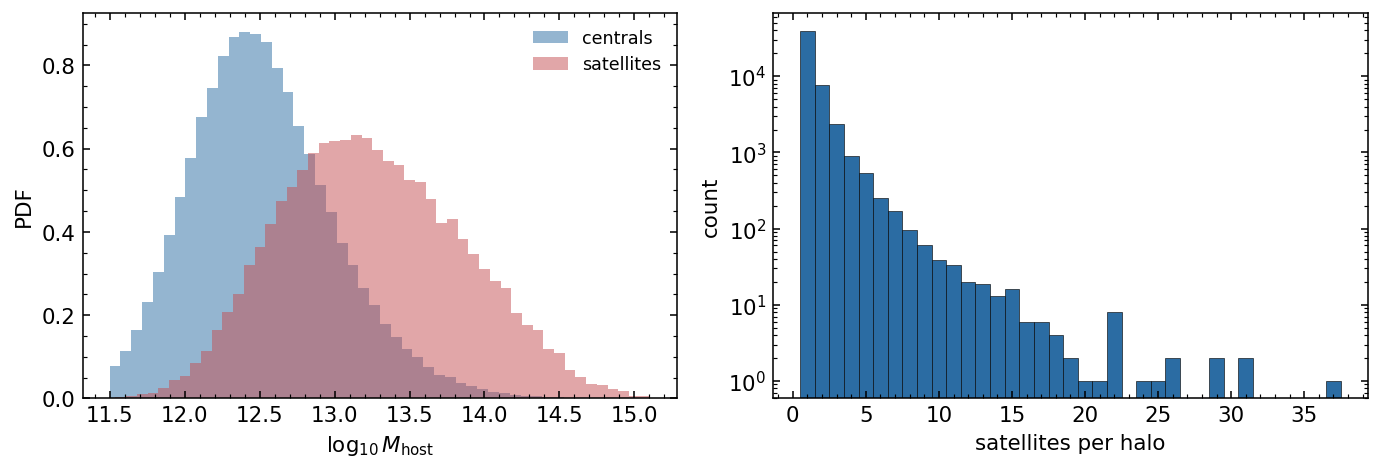

In [19]:
host_mass = halo_masses[halo_idx]
_, sat_counts = np.unique(halo_idx[~is_cen], return_counts=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.hist(np.log10(host_mass[is_cen]),  bins=50, density=True, alpha=0.5, color='#2b6ca3', label='centrals')
ax1.hist(np.log10(host_mass[~is_cen]), bins=50, density=True, alpha=0.5, color='#c44e52', label='satellites')
ax1.set_xlabel(r'$\log_{10} M_{\rm host}$')
ax1.set_ylabel('PDF')
ax1.legend()

ax2.hist(sat_counts, bins=np.arange(0.5, sat_counts.max()+1.5),
         color='#2b6ca3', edgecolor='k', linewidth=0.3)
ax2.set_xlabel('satellites per halo')
ax2.set_ylabel('count')
ax2.set_yscale('log')

plt.tight_layout(); plt.show()

---

## Validation against halotools

Everything below compares miniHOD to halotools Zheng07. Requires `halotools` and `Corrfunc`.

Two things need matching for a fair comparison. First, miniHOD only draws satellites when a central exists (per-halo conformity); halotools Zheng07 draws them independently, so we post-filter orphan satellites. Second, miniHOD uses exp(-Mcut/M) while Zheng07 uses (M-M0); setting logMcut=-30 effectively disables our cutoff so both codes have the same satellite occupation.

In [20]:
# Shared setup for all validation cells (~30s)
from scipy.special import erf
from halotools.empirical_models import PrebuiltHodModelFactory, NFWProfile
from halotools.sim_manager import UserSuppliedHaloCatalog
from Corrfunc.theory.wp import wp as corrfunc_wp

# Regenerate catalog with clustered positions (needed for wp)
def _lognormal_positions(N_target, box, seed=0, Ng=256):
    rng = np.random.default_rng(seed)
    kx = np.fft.fftfreq(Ng, d=box/(2*np.pi*Ng))
    kz = np.fft.rfftfreq(Ng, d=box/(2*np.pi*Ng))
    KX, KY, KZ = np.meshgrid(kx, kx, kz, indexing='ij')
    K = np.sqrt(KX**2 + KY**2 + KZ**2)
    K[0,0,0] = 2*np.pi/box
    q = K / 0.21
    T = np.log(1+2.34*q)/(2.34*q) / (1+3.89*q+(16.2*q)**2+(5.47*q)**3+(6.71*q)**4)**0.25
    T[0,0,0] = 1.0
    Pk = K**0.96 * T**2; Pk[0,0,0] = 0.0
    Vc, Vb = (box/Ng)**3, box**3
    s2 = np.sum(Pk)*Vc/Vb*(2*np.pi)**3/Vb
    if s2 > 0: Pk *= 0.3/s2
    amp = np.sqrt(Pk); amp[0,0,0] = 0.0
    dk = amp*(rng.standard_normal(amp.shape) + 1j*rng.standard_normal(amp.shape))
    dr = np.fft.irfftn(dk, s=(Ng,)*3)
    std = dr.std()
    if std > 0: dr = dr/std * np.sqrt(np.log(1.5))
    rho = np.exp(dr - 0.5*dr.var()); rho /= rho.mean(); rho = np.minimum(rho, 500.0)
    n = rng.poisson(rho * N_target / Ng**3)
    ix,iy,iz = np.where(n>0); c = n[ix,iy,iz]; tot = int(c.sum()); cell = box/Ng
    return np.column_stack([(np.repeat(ix,c)+rng.uniform(size=tot))*cell,
                            (np.repeat(iy,c)+rng.uniform(size=tot))*cell,
                            (np.repeat(iz,c)+rng.uniform(size=tot))*cell])

rng2 = np.random.default_rng(42)
logM_p = rng2.uniform(11.5, 15.2, 25_000_000)
M_p = 10**logM_p
w = M_p**(-0.9) * np.exp(-(M_p/10**13.8)**0.6)
masses = M_p[rng2.uniform(size=len(w)) < w/w.max()][:2_500_000]
cpos = _lognormal_positions(len(masses), BOX, seed=0)
Nc = min(len(masses), len(cpos))
masses, cpos = masses[:Nc], cpos[:Nc]
cvel = rng2.normal(0, 300, (Nc, 3))
rvir = NFWProfile().halo_mass_to_halo_radius(masses)

model_v = HOD(masses, cpos, cvel, rvir, box_size=BOX)

ids = np.arange(Nc)
halocat = UserSuppliedHaloCatalog(
    Lbox=BOX, particle_mass=1e9, redshift=0.0,
    halo_id=ids, halo_upid=np.full(Nc,-1), halo_hostid=ids,
    halo_x=cpos[:,0], halo_y=cpos[:,1], halo_z=cpos[:,2],
    halo_vx=cvel[:,0], halo_vy=cvel[:,1], halo_vz=cvel[:,2],
    halo_mvir=masses, halo_rvir=rvir,
    halo_nfw_conc=10.14*(masses/2e12)**(-0.081),
)
ht = PrebuiltHodModelFactory('zheng07', redshift=0.0)
HT_PARAMS = {'logMmin': 12.5, 'sigma_logM': 0.5, 'logM1': 13.5, 'logM0': 0.0, 'alpha': 1.0}
ht.param_dict.update(HT_PARAMS)

COMPARE = dict(logMmin=12.5, sigma_logM=0.5, fmax=1.0, logMsat=13.5, logMcut=-30.0, alpha=1.0)
HOD_PARAMS = dict(logMmin=12.5, sigma_logM=0.5, fmax=1.0, logMsat=13.5, logMcut=11.5, alpha=1.0)

def _ht_no_orphans(seed):
    """Populate halotools and remove satellites in halos without a central."""
    ht.populate_mock(halocat, seed=seed)
    gt = ht.mock.galaxy_table
    ic = np.array(gt['gal_type'] == 'centrals')
    hosts_with_cen = set(gt['halo_hostid'][ic])
    hid = np.array(gt['halo_hostid'])
    keep = ic | np.isin(hid, list(hosts_with_cen))
    return {'pos': np.column_stack([gt['x'][keep], gt['y'][keep], gt['z'][keep]]),
            'vel': np.column_stack([gt['vx'][keep], gt['vy'][keep], gt['vz'][keep]]),
            'is_central': ic[keep]}

N_REAL = 10
mini_cats = [model_v.populate(**COMPARE, seed=s) for s in range(N_REAL)]
ht_cats = [_ht_no_orphans(s) for s in range(N_REAL)]

print(f'Setup done: {Nc:,} halos, {N_REAL} realizations each')

/var/folders/tp/c27jt40x54d01j_zktwxzql80000gn/T/ipykernel_90550/444988558.py:24: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  dr = np.fft.irfftn(dk, s=(Ng,)*3)


Setup done: 2,498,559 halos, 10 realizations each


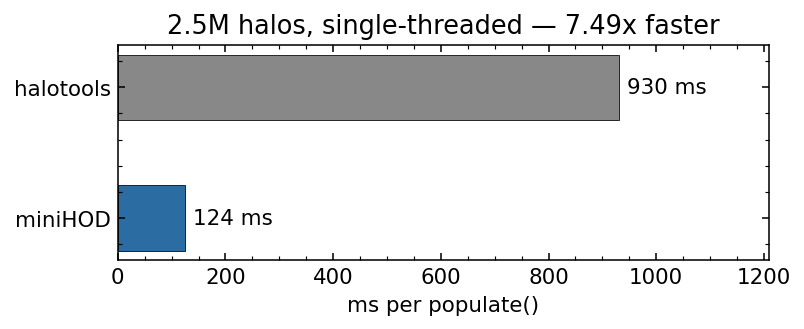

In [29]:
# Benchmark: miniHOD vs halotools, single-threaded
N_RUNS = 10

_ = model_v.populate(**HOD_PARAMS, seed=0, nthreads=1)
t0 = time.perf_counter()
for i in range(N_RUNS): model_v.populate(**HOD_PARAMS, seed=i, nthreads=1)
t_mini = (time.perf_counter() - t0) / N_RUNS * 1e3

ht.populate_mock(halocat, seed=0)
t0 = time.perf_counter()
for i in range(N_RUNS): ht.populate_mock(halocat, seed=i)
t_ht = (time.perf_counter() - t0) / N_RUNS * 1e3

speedup = t_ht / t_mini

fig, ax = plt.subplots(figsize=(6, 2))
bars = ax.barh(['miniHOD', 'halotools'], [t_mini, t_ht],
               color=['#2b6ca3', '#888'], height=0.5, edgecolor='k', linewidth=0.4)
for b, t in zip(bars, [t_mini, t_ht]):
    ax.text(b.get_width() + 15, b.get_y()+b.get_height()/2, f'{t:.0f} ms', va='center')
ax.set_xlabel('ms per populate()')
ax.set_title(f'{Nc/1e6:.1f}M halos, single-threaded \u2014 {speedup:.2f}x faster')
ax.set_xlim(0, t_ht*1.3)
fig.savefig('docs/benchmark.png', bbox_inches='tight', dpi=200)
plt.show()

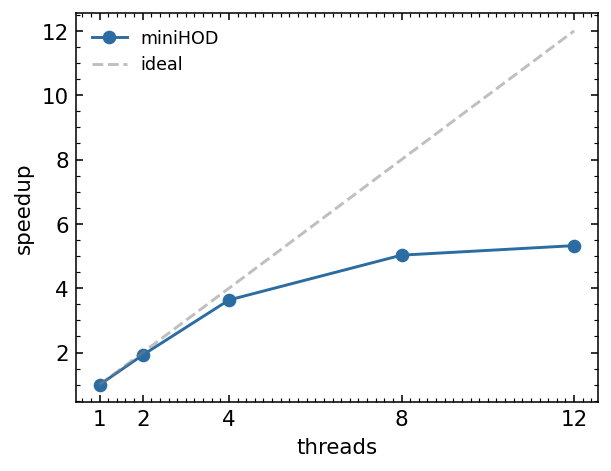

In [22]:
# OpenMP scaling
import multiprocessing
n_cpu = multiprocessing.cpu_count()
threads = sorted(set([1, 2, 4, min(8, n_cpu), n_cpu]))

times = {}
for nt in threads:
    t0 = time.perf_counter()
    for s in range(10): model_v.populate(**HOD_PARAMS, seed=s, nthreads=nt)
    times[nt] = (time.perf_counter() - t0) / 10 * 1e3

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.plot(threads, [times[1]/times[t] for t in threads], 'o-', color='#2b6ca3', label='miniHOD')
ax.plot(threads, threads, '--', color='gray', alpha=0.5, label='ideal')
ax.set_xlabel('threads'); ax.set_ylabel('speedup')
ax.legend(); ax.set_xticks(threads)
plt.tight_layout(); plt.show()

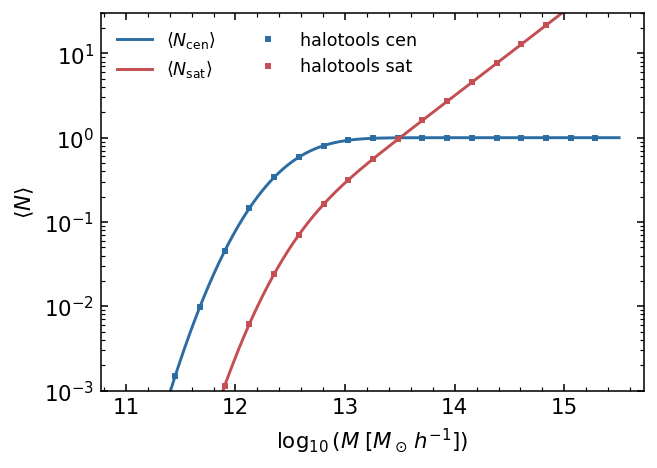

In [23]:
# Occupation functions
logM = np.linspace(11, 15.5, 500)
M = 10**logM

Ncen = 0.5 * (1 + erf((logM - 12.5) / 0.5))
Nsat = Ncen * (M / 10**13.5)  # alpha=1, logMcut=-30 so exp term ~ 1

nc_ht = ht.mean_occupation_centrals(prim_haloprop=M)
ns_ht = nc_ht * ht.mean_occupation_satellites(prim_haloprop=M)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.semilogy(logM, Ncen, '-', color='#2b6ca3', label=r'$\langle N_{\rm cen}\rangle$')
ax.semilogy(logM, Nsat, '-', color='#c44e52', label=r'$\langle N_{\rm sat}\rangle$')
ax.semilogy(logM, nc_ht, 's', color='#2b6ca3', ms=2, markevery=25, label='halotools cen')
ax.semilogy(logM, ns_ht, 's', color='#c44e52', ms=2, markevery=25, label='halotools sat')
ax.set_xlabel(r'$\log_{10}(M\;[M_\odot\,h^{-1}])$')
ax.set_ylabel(r'$\langle N \rangle$')
ax.set_ylim(1e-3, 30); ax.legend(ncol=2)
fig.savefig('docs/occupation.png', bbox_inches='tight', dpi=200)
plt.show()

In [24]:
# Number density and central fraction across 10 realizations
n_m = np.array([len(g['pos'])/BOX**3 for g in mini_cats])
n_h = np.array([len(g['pos'])/BOX**3 for g in ht_cats])
f_m = np.array([g['is_central'].mean() for g in mini_cats])
f_h = np.array([g['is_central'].mean() for g in ht_cats])

print(f'{"":20s} {"miniHOD":>15s} {"halotools":>15s}')
print(f'{"n_gal":20s} {n_m.mean():.4e}    {n_h.mean():.4e}')
print(f'{"f_central":20s} {f_m.mean():.4f}         {f_h.mean():.4f}')

                             miniHOD       halotools
n_gal                4.3075e-04    4.3036e-04
f_central            0.8055         0.7995


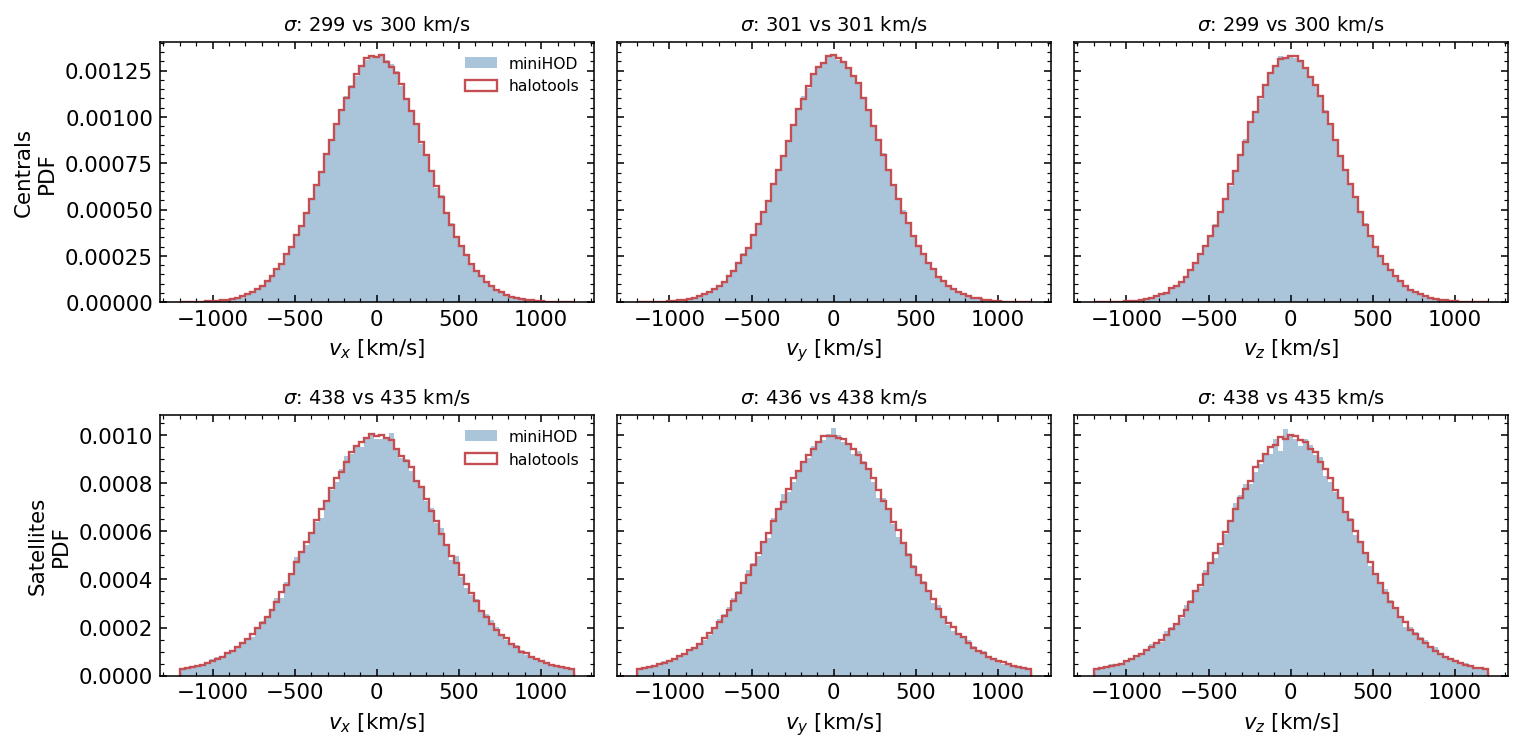

In [25]:
# Velocity distributions
fig, axes = plt.subplots(2, 3, figsize=(11, 5.5), sharey='row')
bins = np.linspace(-1200, 1200, 80)

for row, (label, sel) in enumerate([
    ('Centrals',   lambda g: g['is_central']),
    ('Satellites', lambda g: ~g['is_central']),
]):
    for k, (ax, comp) in enumerate(zip(axes[row], [r'$v_x$', r'$v_y$', r'$v_z$'])):
        v_mini = np.concatenate([g['vel'][sel(g), k] for g in mini_cats])
        v_ht   = np.concatenate([g['vel'][sel(g), k] for g in ht_cats])
        ax.hist(v_mini, bins=bins, density=True, histtype='stepfilled',
                alpha=0.4, color='#2b6ca3', label='miniHOD')
        ax.hist(v_ht, bins=bins, density=True, histtype='step',
                color='#c44e52', lw=1.2, label='halotools')
        ax.set_xlabel(f'{comp} [km/s]')
        if k == 0:
            ax.set_ylabel(f'{label}\nPDF')
            ax.legend(fontsize=8)
        ax.set_title(rf'$\sigma$: {v_mini.std():.0f} vs {v_ht.std():.0f} km/s', fontsize=10)

plt.tight_layout(); plt.show()

Computing wp(rp)...
Done.


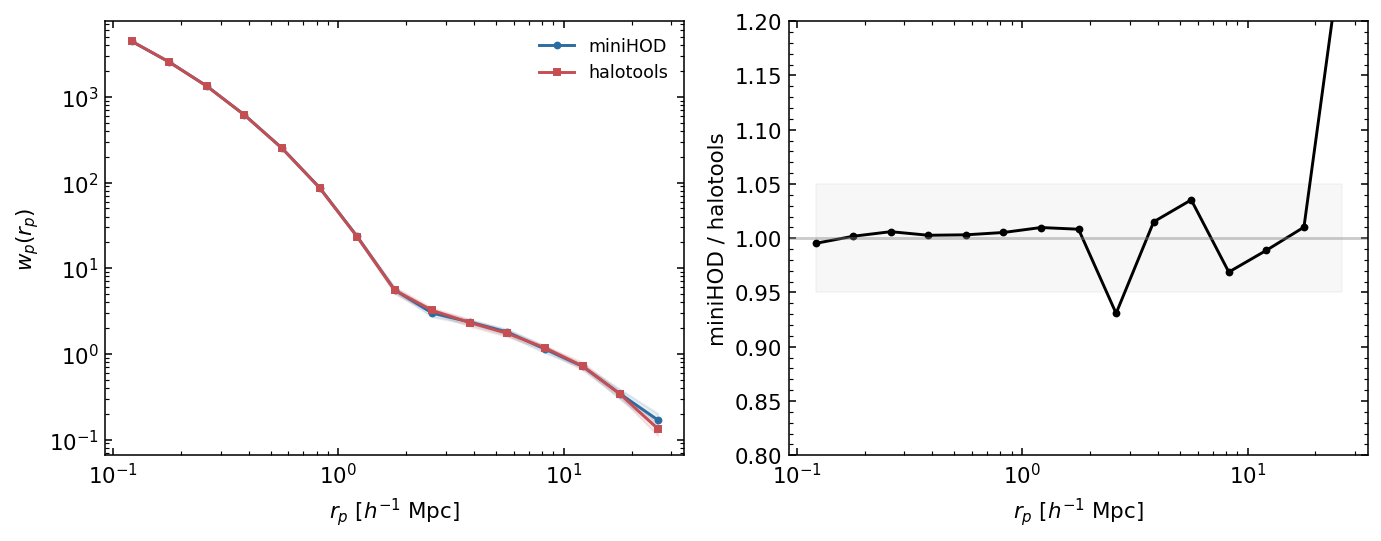

In [26]:
# wp(rp) -- this takes a couple minutes
rp_bins = np.logspace(-1, 1.5, 16)

def _wp(pos):
    return corrfunc_wp(boxsize=BOX, pimax=40.0, nthreads=2, binfile=rp_bins,
                       X=pos[:,0], Y=pos[:,1], Z=pos[:,2])['wp']

print('Computing wp(rp)...')
wp_m = np.array([_wp(model_v.populate(**COMPARE, seed=s)['pos']) for s in range(N_REAL)])
wp_h = np.array([_wp(_ht_no_orphans(s)['pos']) for s in range(N_REAL)])
rp = np.sqrt(rp_bins[:-1] * rp_bins[1:])
print('Done.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for arr, c, m, lab in [(wp_m, '#2b6ca3', 'o', 'miniHOD'), (wp_h, '#c44e52', 's', 'halotools')]:
    ax1.fill_between(rp, arr.mean(0)-arr.std(0), arr.mean(0)+arr.std(0), alpha=0.12, color=c)
    ax1.loglog(rp, arr.mean(0), m+'-', color=c, ms=3, label=lab)
ax1.set_xlabel(r'$r_p$ [$h^{-1}$ Mpc]'); ax1.set_ylabel(r'$w_p(r_p)$'); ax1.legend()

ratio = wp_m.mean(0) / np.where(wp_h.mean(0)>0, wp_h.mean(0), np.nan)
ax2.semilogx(rp, ratio, 'ko-', ms=3)
ax2.axhline(1, color='gray', alpha=0.4)
ax2.fill_between(rp, 0.95, 1.05, alpha=0.06, color='gray')
ax2.set_xlabel(r'$r_p$ [$h^{-1}$ Mpc]'); ax2.set_ylabel('miniHOD / halotools')
ax2.set_ylim(0.8, 1.2)
plt.tight_layout(); plt.show()

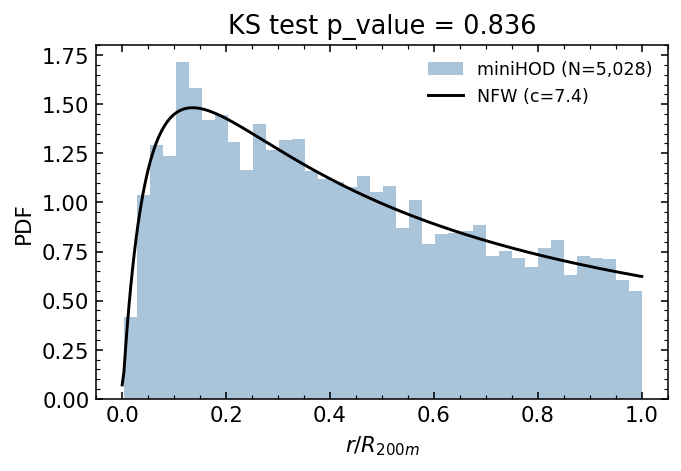

In [28]:
# NFW radial profile KS test
from scipy.stats import kstest

M0 = 1e14
box_nfw = 2000.0
m_nfw = HOD(np.array([M0]), np.array([[box_nfw/2]*3]),
            np.zeros((1,3)), np.array([1.0]), box_size=box_nfw)

sats = []
for s in range(50):
    g = m_nfw.populate(logMmin=10.0, sigma_logM=0.1, fmax=1.0,
                       logMsat=np.log10(M0/100), logMcut=8.0, alpha=1.0, seed=s)
    sats.append(g['pos'][~g['is_central']].copy())
sats = np.concatenate(sats)

dr = sats - box_nfw/2
dr -= box_nfw * np.round(dr/box_nfw)
r = np.linalg.norm(dr, axis=1)

c = 10.14 * (M0/2e12)**(-0.081)  # Duffy+08
nfw_cdf = lambda x: (np.log(1+c*x) - c*x/(1+c*x)) / (np.log(1+c) - c/(1+c))
stat, pval = kstest(r, nfw_cdf)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(r, bins=40, density=True, histtype='stepfilled', alpha=0.4, color='#2b6ca3',
        label=f'miniHOD (N={len(r):,})')
x = np.linspace(0, 1, 300)
ax.plot(x, np.gradient(nfw_cdf(x), x), 'k-', lw=1.5, label=f'NFW (c={c:.1f})')
ax.set_xlabel(r'$r/R_{200m}$'); ax.set_ylabel('PDF')
ax.set_title(f'KS test p_value = {pval:.3f}')
ax.legend()
plt.tight_layout(); plt.show()